In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import matplotlib
matplotlib.rcParams["figure.figsize"] = (20,10)

# **Reading the csv file into pandas DataFrame. Prices(Target variable) is Lakhs**

In [4]:
df = pd.read_csv('bengaluru_house_prices.csv')
df.head()

,area_type,availability,location,size,society,total_sqft,bath,balcony,price
0,Super built-up Area,19-Dec,Electronic City Phase II,2 BHK,Coomee,1056,2.0,1.0,39.07
1,Plot Area,Ready To Move,Chikka Tirupathi,4 Bedroom,Theanmp,2600,5.0,3.0,120.00
2,Built-up Area,Ready To Move,Uttarahalli,3 BHK,NaN,1440,2.0,3.0,62.00
3,Super built-up Area,Ready To Move,Lingadheeranahalli,3 BHK,Soiewre,1521,3.0,1.0,95.00
4,Super built-up Area,Ready To Move,Kothanur,2 BHK,NaN,1200,2.0,1.0,51.00


In [5]:
df.shape

(13320, 9)

In [6]:
df.groupby('area_type')['area_type'].agg('count')

,area_type
area_type,
Built-up Area,2418
Carpet Area,87
Plot Area,2025
Super built-up Area,8790


In [7]:
df2 = df.drop(['area_type', 'society', 'balcony', 'availability'], axis=1)
df2.head()

,location,size,total_sqft,bath,price
0,Electronic City Phase II,2 BHK,1056,2.0,39.07
1,Chikka Tirupathi,4 Bedroom,2600,5.0,120.00
2,Uttarahalli,3 BHK,1440,2.0,62.00
3,Lingadheeranahalli,3 BHK,1521,3.0,95.00
4,Kothanur,2 BHK,1200,2.0,51.00


# **Data Cleaning**

In [8]:
df2.isna().sum()

,0
location,1
size,16
total_sqft,0
bath,73
price,0


**NA values in each given colums is very much small compared to the total dataframe size. So we can safely drop it.**

In [9]:
df3 = df2.dropna()
df3.isna().sum()

,0
location,0
size,0
total_sqft,0
bath,0
price,0


**size has different unique values but some are same in terms of its meaning.**
**for eg, 2 BHK = 2 Bedroom**

In [10]:
df3['size'].unique()

array(['2 BHK', '4 Bedroom', '3 BHK', '4 BHK', '6 Bedroom', '3 Bedroom',
       '1 BHK', '1 RK', '1 Bedroom', '8 Bedroom', '2 Bedroom',
       '7 Bedroom', '5 BHK', '7 BHK', '6 BHK', '5 Bedroom', '11 BHK',
       '9 BHK', '9 Bedroom', '27 BHK', '10 Bedroom', '11 Bedroom',
       '10 BHK', '19 BHK', '16 BHK', '43 Bedroom', '14 BHK', '8 BHK',
       '12 Bedroom', '13 BHK', '18 Bedroom'], dtype=object)

**Creating a new column bhk and take the numbers only as integers**

In [11]:
df3['bhk'] = df3['size'].apply(lambda x: int(x.split(' ')[0]))
df3.sample(5)

/tmp/ipython-input-1306187683.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df3['bhk'] = df3['size'].apply(lambda x: int(x.split(' ')[0]))


,location,size,total_sqft,bath,price,bhk
10,Whitefield,3 BHK,1800,2.0,70.00,3
7463,Poorna Pragna Layout,2 BHK,1160,2.0,46.39,2
4724,"Hoodi Circle,",4 BHK,2107,4.0,95.00,4
792,Thanisandra,2 BHK,1296,2.0,83.00,2
6285,8th Block Jayanagar,2 BHK,1100,2.0,110.00,2


In [12]:
df3.bhk.unique()

array([ 2,  4,  3,  6,  1,  8,  7,  5, 11,  9, 27, 10, 19, 16, 43, 14, 12,
       13, 18])

In [13]:
df3[df3.bhk>20]

,location,size,total_sqft,bath,price,bhk
1718,2Electronic City Phase II,27 BHK,8000,27.0,230.0,27
4684,Munnekollal,43 Bedroom,2400,40.0,660.0,43


**The 43 Bedroom with 2400 total_sqft is not possible. That is some kind of error. We try to remove it later**

In [14]:
df3['total_sqft'].unique()

array(['1056', '2600', '1440', ..., '1133 - 1384', '774', '4689'],
      dtype=object)

**Trying to remove the range values in total_sqft as follows:**

1. Creating a function is_float() for extracting the range values and other unstructured types in the dataframe.
2. ~ is bitwise not which makes true to false and viceversa.
3. Creating another function which takes the ranges as input and converting the avg value of them. String number values are directls convert to float and other unstructured types are convert to NAN.

In [15]:
def is_float(x):
  try:
    float(x)
  except:
    return False
  return True

In [16]:
df3[~df3['total_sqft'].apply(is_float)].head(10)

,location,size,total_sqft,bath,price,bhk
30,Yelahanka,4 BHK,2100 - 2850,4.0,186.000,4
122,Hebbal,4 BHK,3067 - 8156,4.0,477.000,4
137,8th Phase JP Nagar,2 BHK,1042 - 1105,2.0,54.005,2
165,Sarjapur,2 BHK,1145 - 1340,2.0,43.490,2
188,KR Puram,2 BHK,1015 - 1540,2.0,56.800,2
410,Kengeri,1 BHK,34.46Sq. Meter,1.0,18.500,1
549,Hennur Road,2 BHK,1195 - 1440,2.0,63.770,2
648,Arekere,9 Bedroom,4125Perch,9.0,265.000,9
661,Yelahanka,2 BHK,1120 - 1145,2.0,48.130,2
672,Bettahalsoor,4 Bedroom,3090 - 5002,4.0,445.000,4


In [17]:
def convert_ranges_to_sqft(x):
  tokens = x.split('-')
  if len(tokens) == 2:
    return (float(tokens[0])+float(tokens[1]))/2
  try:
    return float(x)
  except:
    return None

In [18]:
convert_ranges_to_sqft('2100 - 2850')

2475.0

In [19]:
convert_ranges_to_sqft('1340')

1340.0

In [20]:
convert_ranges_to_sqft('4125Perch')

In [21]:
df4 = df3.copy()
df4['total_sqft'] = df4['total_sqft'].apply(convert_ranges_to_sqft)
df4.head()

,location,size,total_sqft,bath,price,bhk
0,Electronic City Phase II,2 BHK,1056.0,2.0,39.07,2
1,Chikka Tirupathi,4 Bedroom,2600.0,5.0,120.00,4
2,Uttarahalli,3 BHK,1440.0,2.0,62.00,3
3,Lingadheeranahalli,3 BHK,1521.0,3.0,95.00,3
4,Kothanur,2 BHK,1200.0,2.0,51.00,2


In [22]:
df4.loc[122]

,122
location,Hebbal
size,4 BHK
total_sqft,5611.5
bath,4.0
price,477.0
bhk,4


In [23]:
df4.loc[648]

,648
location,Arekere
size,9 Bedroom
total_sqft,NaN
bath,9.0
price,265.0
bhk,9


**Now we are creating a price per sqft column which have larger importance in real estate price prediction**

In [24]:
df5 = df4.copy()
df5.sample(10)

,location,size,total_sqft,bath,price,bhk
5000,Kengeri Hobli,3 BHK,1082.0,2.0,42.00,3
1680,frazertown,3 BHK,2000.0,3.0,210.00,3
11704,Hormavu,2 BHK,1206.0,2.0,55.00,2
12166,Thyagaraja Nagar,2 BHK,1040.0,2.0,68.00,2
9125,Gottigere,2 BHK,1205.0,2.0,56.58,2
4634,Kalyan nagar,3 BHK,1800.0,3.0,85.00,3
11485,Jigani,2 BHK,918.0,2.0,56.00,2
40,Murugeshpalya,2 BHK,1296.0,2.0,81.00,2
11491,CV Raman Nagar,3 BHK,1400.0,2.0,78.00,3
12480,Kattigenahalli,6 Bedroom,3500.0,6.0,115.00,6


In [25]:
df5['price_per_sqft'] = df5['price']*100000/df5['total_sqft']
df5.head()

,location,size,total_sqft,bath,price,bhk,price_per_sqft
0,Electronic City Phase II,2 BHK,1056.0,2.0,39.07,2,3699.810606
1,Chikka Tirupathi,4 Bedroom,2600.0,5.0,120.00,4,4615.384615
2,Uttarahalli,3 BHK,1440.0,2.0,62.00,3,4305.555556
3,Lingadheeranahalli,3 BHK,1521.0,3.0,95.00,3,6245.890861
4,Kothanur,2 BHK,1200.0,2.0,51.00,2,4250.000000


# **Dimensionality checking and reducing dimensionality curse**

In [26]:
df5.location.unique()

array(['Electronic City Phase II', 'Chikka Tirupathi', 'Uttarahalli', ...,
       '12th cross srinivas nagar banshankari 3rd stage',
       'Havanur extension', 'Abshot Layout'], dtype=object)

In [27]:
df5.location.nunique()

1304

**We can't make a dummy 1304 cols which make the dataframe complex and cause dimensionality curse. There are certain techniques to reduce these dimensionality.**


1.   First we group dataframe based on locations where we get the no. of rows under each unique location.
2.   We merging the locations with 10 or less rows to a new location named as 'other'.
3.  Now we reduce the unique locations in the location column and thereby reducing the dimensionality curse.







In [28]:
df5.location = df5.location.apply(lambda x: x.strip()) # striping leading or tailing spaces

In [29]:
location_stats = df5.groupby('location')['location'].agg('count').sort_values(ascending=False) #sorting in descending order
location_stats

,location
location,
Whitefield,535
Sarjapur Road,392
Electronic City,304
Kanakpura Road,266
Thanisandra,236
...,...
poornaprajna layout,1
pavitra paradise,1
near Ramanashree California resort,1


In [30]:
locations_with_rows_less_than_10 = location_stats[location_stats <= 10]
locations_with_rows_less_than_10.shape

(1052,)

In [31]:
df5.location = df5['location'].apply(lambda x: 'other' if x in locations_with_rows_less_than_10 else x)
df5.sample(10)

,location,size,total_sqft,bath,price,bhk,price_per_sqft
7161,Hennur,3 Bedroom,1000.0,3.0,130.00,3,13000.000000
4979,Hosa Road,2 BHK,1016.0,2.0,40.00,2,3937.007874
12771,Electronics City Phase 1,2 BHK,1088.0,2.0,30.46,2,2799.632353
8742,JP Nagar,1 BHK,745.0,1.0,34.27,1,4600.000000
12558,LB Shastri Nagar,2 BHK,1200.0,2.0,47.00,2,3916.666667
7397,Vittasandra,2 BHK,1246.0,2.0,67.30,2,5401.284109
9131,Sanjay nagar,2 BHK,960.0,2.0,55.00,2,5729.166667
492,Hoodi,2 BHK,1196.0,2.0,94.42,2,7894.648829
8788,9th Phase JP Nagar,2 BHK,1073.0,2.0,52.36,2,4879.776328
13065,Whitefield,3 BHK,1564.0,3.0,103.00,3,6585.677749


In [32]:
df5.location.nunique()

242

# **Outlier Removal**

**Outliers are some extreme variations in data points in the dataframe which causes prediction errors. There are different techniques to detect and remove them.**

**For eg, if total_sqft for 1 bedroom is 300, then belowing this 300 ia an outlier. We can extract some rows that violates the above condition:**

In [33]:
df5[df5.total_sqft/df5.bhk < 300].head(5)

,location,size,total_sqft,bath,price,bhk,price_per_sqft
9,other,6 Bedroom,1020.0,6.0,370.0,6,36274.509804
45,HSR Layout,8 Bedroom,600.0,9.0,200.0,8,33333.333333
58,Murugeshpalya,6 Bedroom,1407.0,4.0,150.0,6,10660.980810
68,Devarachikkanahalli,8 Bedroom,1350.0,7.0,85.0,8,6296.296296
70,other,3 Bedroom,500.0,3.0,100.0,3,20000.000000


In [34]:
df5.shape

(13246, 7)

In [35]:
df6 = df5[~(df5.total_sqft/df5.bhk < 300)]
df6.shape

(12502, 7)

In [36]:
df6.describe()

,total_sqft,bath,price,bhk,price_per_sqft
count,12456.000000,12502.000000,12502.000000,12502.000000,12456.000000
mean,1590.189927,2.564790,111.311915,2.650696,6308.502826
std,1260.404795,1.084946,152.089966,0.981698,4168.127339
min,300.000000,1.000000,9.000000,1.000000,267.829813
25%,1115.000000,2.000000,49.000000,2.000000,4210.526316
50%,1300.000000,2.000000,70.000000,3.000000,5294.117647
75%,1700.000000,3.000000,115.000000,3.000000,6916.666667
max,52272.000000,16.000000,3600.000000,16.000000,176470.588235


**Creating a function which will remove the outliers based on the location with help of mean and standard deviation as follows:**

In [37]:
def remove_pps_outliers(df):
  df_out = pd.DataFrame()
  for key, subdf in df.groupby('location'):
    m = np.mean(subdf.price_per_sqft)
    st = np.std(subdf.price_per_sqft)
    reduced_df = subdf[(subdf.price_per_sqft>(m-st)) & (subdf.price_per_sqft<=(m+st))]
    df_out = pd.concat([df_out, reduced_df], ignore_index=True)
  return df_out

In [38]:
df6.shape

(12502, 7)

In [39]:
df7 = remove_pps_outliers(df6)
df7.shape

(10241, 7)

**In some cases on the same sqft area there are prices of 2 bedrooms with is larger than 3 bedrooms larger than 4...so on..**

**We can understand it by defining a function which will plot a graph based on location as given below:**

In [40]:
def  plot_scatter(df, loc):
  matplotlib.rcParams['figure.figsize'] = (15,10)
  bhk2 = df[(df['location'] == loc) & (df.bhk == 2)]
  bhk3 = df[(df['location'] == loc) & (df.bhk == 3)]
  sns.scatterplot(bhk2, x='total_sqft', y='price', color='blue', label='2 BHK')
  sns.scatterplot(bhk3, x='total_sqft', y='price', color='red', label='3 BHK')
  plt.xlabel('Total Sqft Area')
  plt.ylabel('Price')
  plt.title(loc)
  plt.legend()
  plt.show()

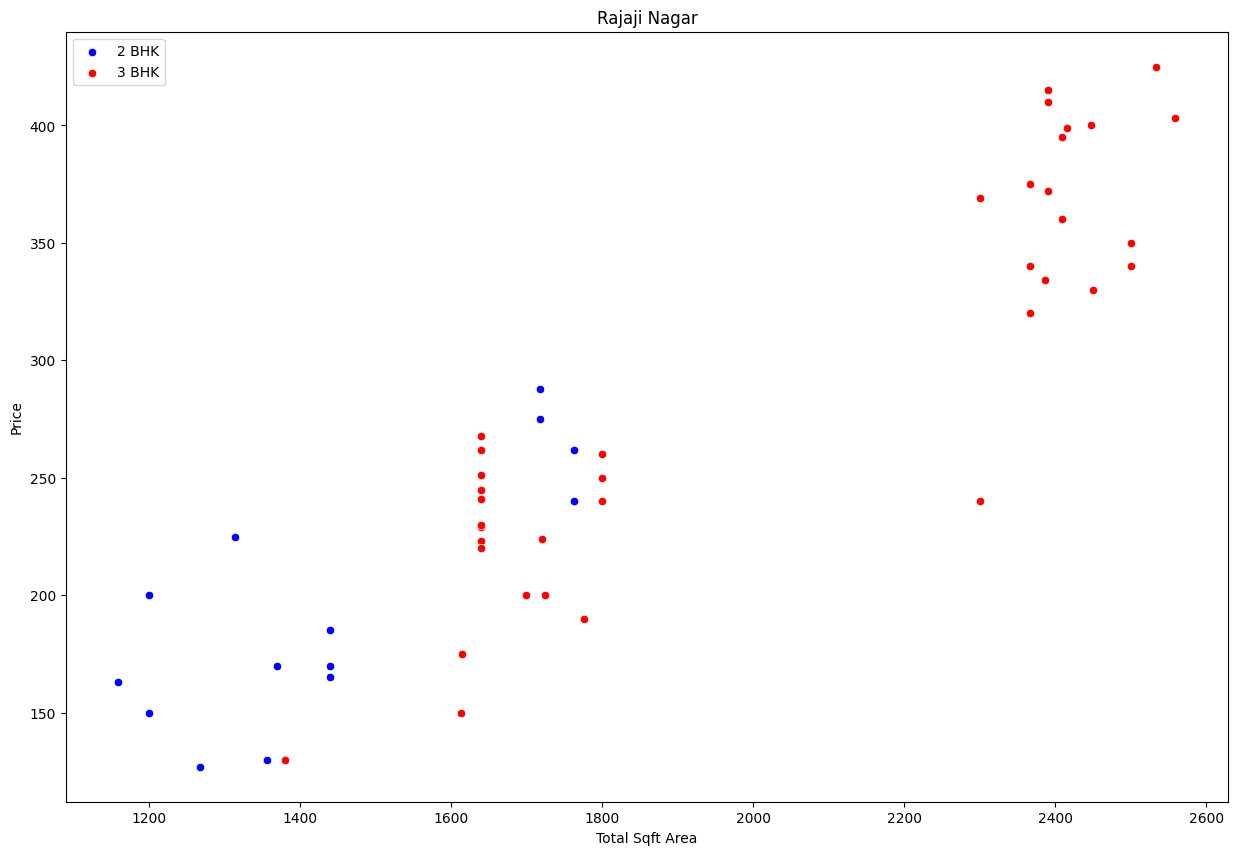

In [41]:
plot_scatter(df7, 'Rajaji Nagar')

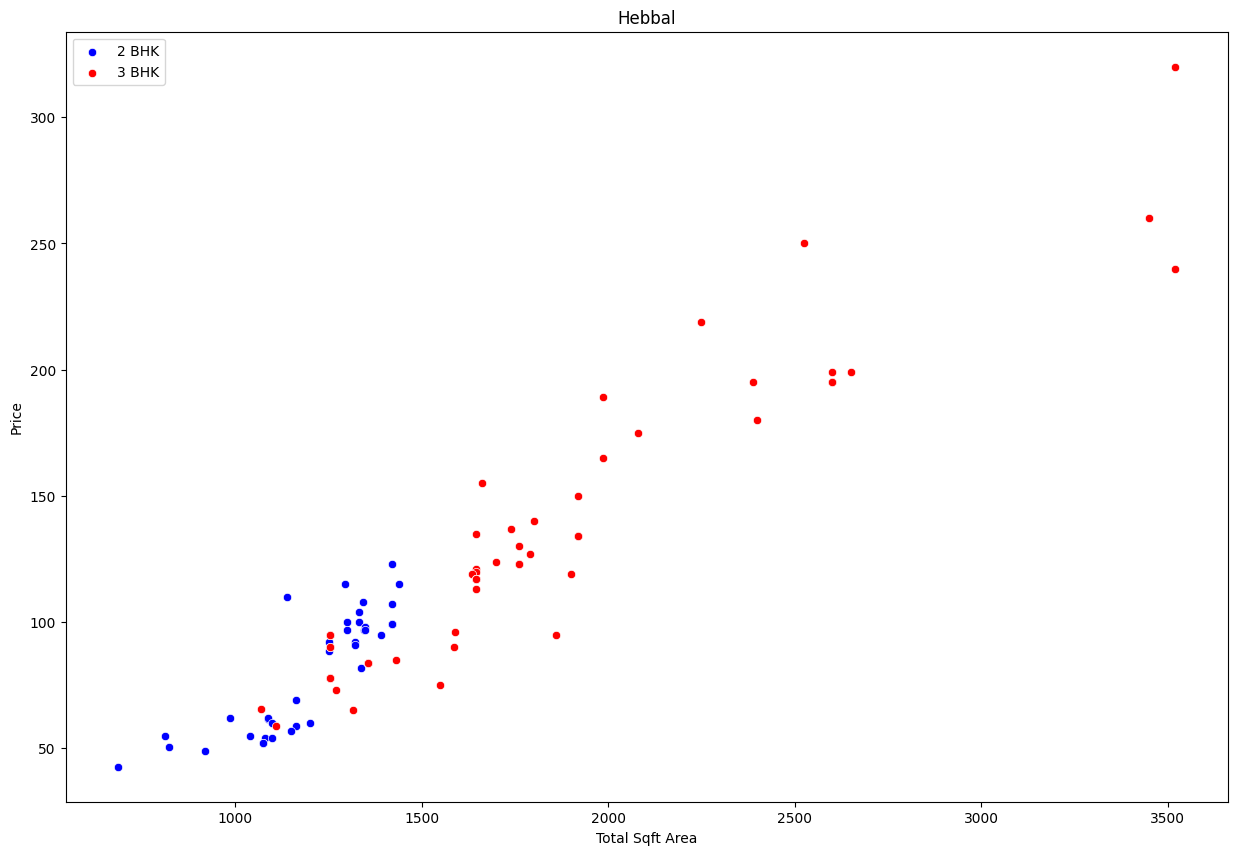

In [42]:
plot_scatter(df7, 'Hebbal')

**Here both Rajaji Nagar and Hebbal we found the price of 2 Bedrooms is greater than 3 bedrooms where the sqft area is approx equal...We can find more cases.**

**Now we trying to remove such ooutliers by creating a new function:**


1.   The function grouped based on location and then grouped again based on the bhk(no. of bedrooms) where the mean, std and count of bedrooms are stored as a dictionary.
2.   Dict like this:
    '1': {
      'mean': 4000,
      'std': 2200,
      'count': 23
    }, ...... etc
3.    The bedrooms at the same location and approx equal area which will less price than its previous one in dict(for 2 its previous is 1) will be removed from the dataframe.



In [43]:
def remove_bhk_outliers(df):
  exclude_indices = np.array([])
  for loc, loc_df in df.groupby('location'):
    bhk_stats = {}
    for bhk, bhk_df in loc_df.groupby('bhk'):
      bhk_stats[bhk] = {
          'mean': np.mean(bhk_df.price_per_sqft),
          'std': np.std(bhk_df.price_per_sqft),
          'count': bhk_df.shape[0]
      }
    for bhk, bhk_df in loc_df.groupby('bhk'):
      stats = bhk_stats.get(bhk-1)
      if stats and stats['count']>5:
        exclude_indices = np.append(exclude_indices, bhk_df[bhk_df.price_per_sqft<stats['mean']].index.values)
  return df.drop(exclude_indices, axis='index')

In [44]:
df7.shape

(10241, 7)

In [45]:
df8 = remove_bhk_outliers(df7)
df8.shape

(7329, 7)

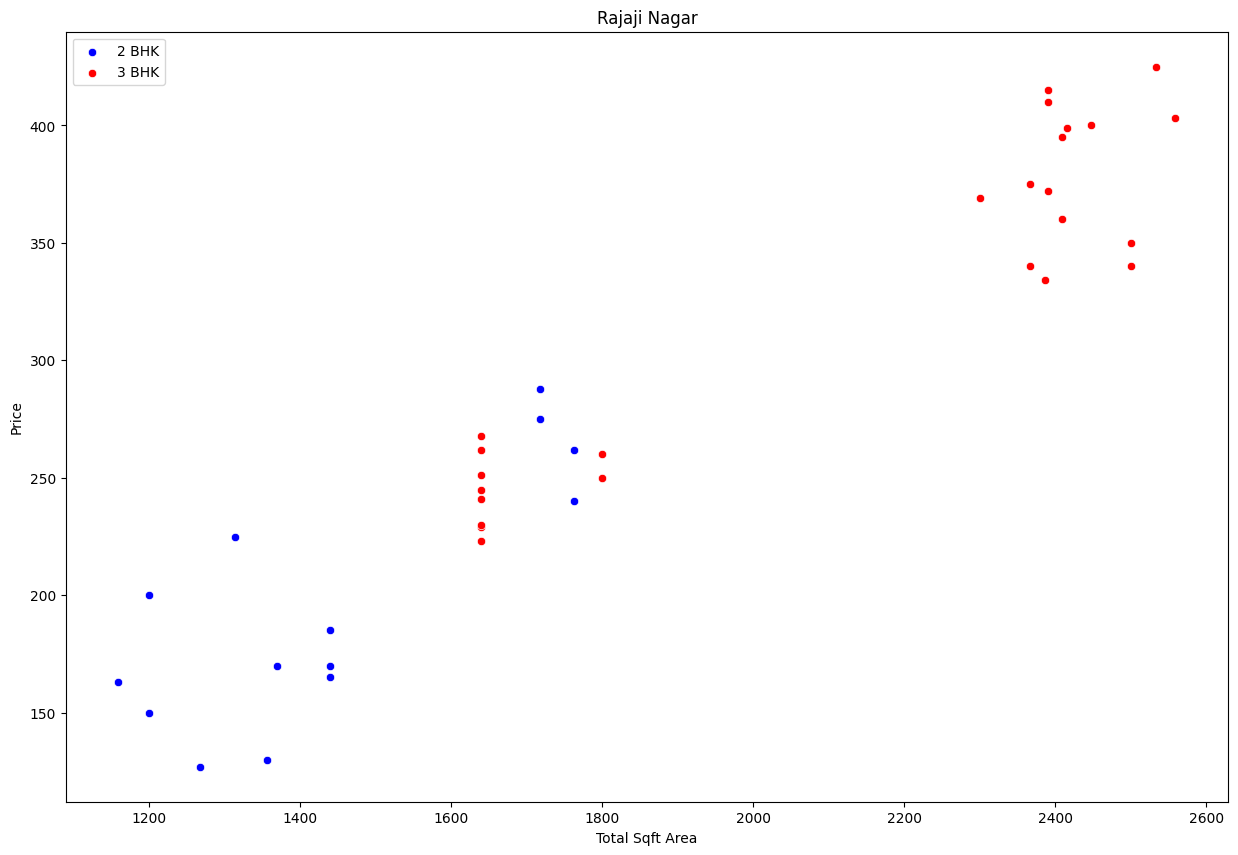

In [46]:
plot_scatter(df8, 'Rajaji Nagar')

**Now from the given scatterplot the outliers are removed.**

**Showing a histogram of no. of datapoints vs price per sqft. It looks like a normal distribution of bell curved shape.**

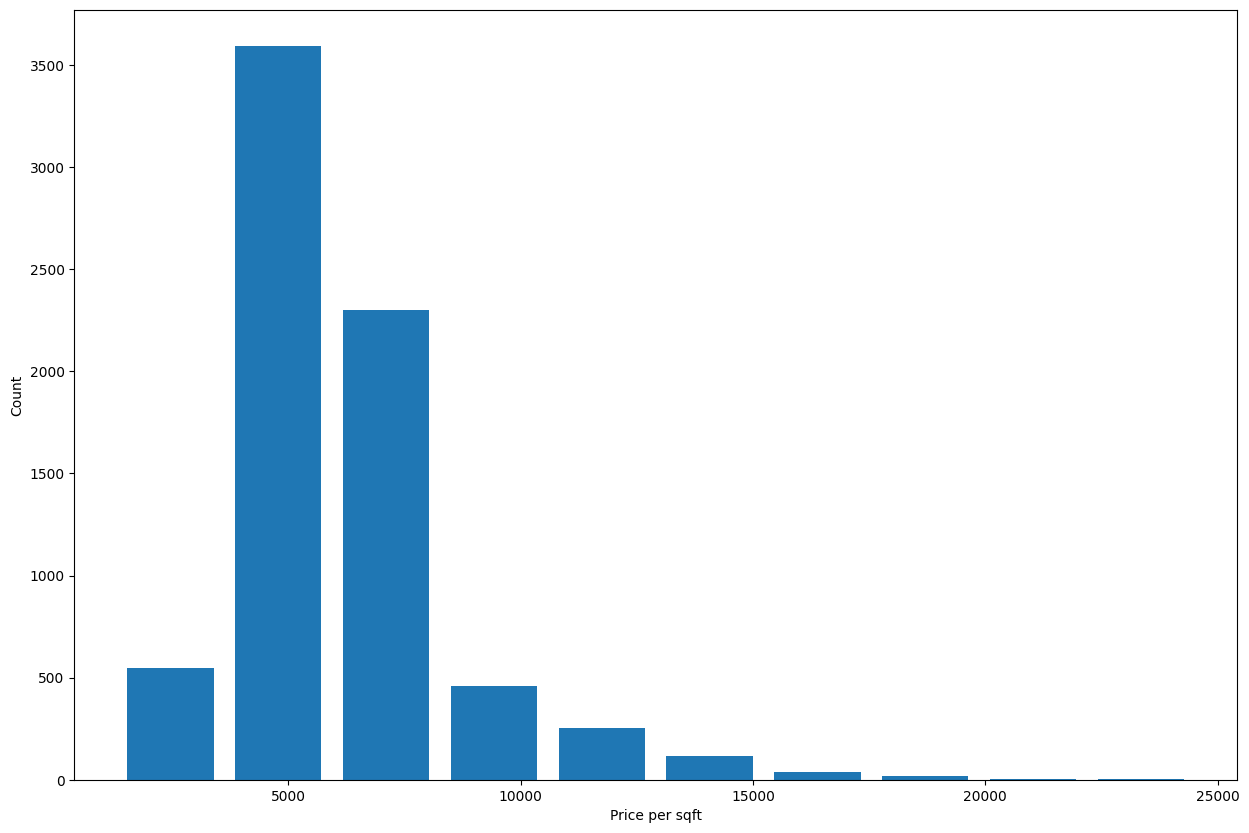

In [47]:
plt.hist(df8.price_per_sqft, rwidth=0.8)
plt.xlabel('Price per sqft')
plt.ylabel('Count')
plt.show()

In [48]:
df8.bath.unique()

array([ 4.,  3.,  2.,  5.,  8.,  1.,  6.,  7.,  9., 12., 16., 13.])

In [49]:
df8[df8.bath>10]

,location,size,total_sqft,bath,price,bhk,price_per_sqft
5277,Neeladri Nagar,10 BHK,4000.0,12.0,160.0,10,4000.000000
8486,other,10 BHK,12000.0,12.0,525.0,10,4375.000000
8575,other,16 BHK,10000.0,16.0,550.0,16,5500.000000
9308,other,11 BHK,6000.0,12.0,150.0,11,2500.000000
9639,other,13 BHK,5425.0,13.0,275.0,13,5069.124424


**Now we can understand from the above table that the no. of bathrooms sometimes is large no than other rooms. It si also some kind of outlier.**

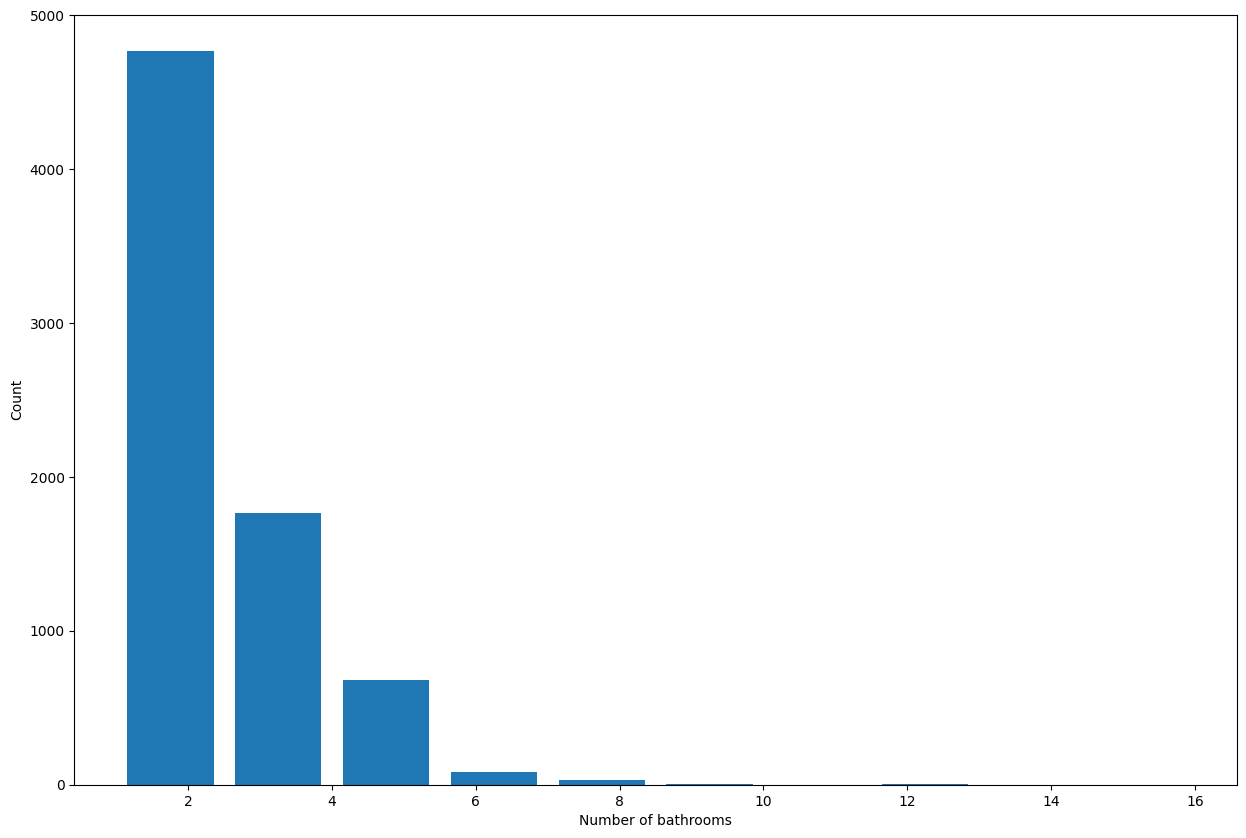

In [50]:
plt.hist(df8.bath, rwidth=0.8)
plt.xlabel('Number of bathrooms')
plt.ylabel('Count')
plt.show()

**Whenever the no. of bathrooms is graeter than the no. of bedrooms + 2, we can mark it has an outlier and remove it from the dataframe. The following table showing the outliers and we trying to remove it.**

In [51]:
df8[df8.bath>df8.bhk+2]

,location,size,total_sqft,bath,price,bhk,price_per_sqft
1626,Chikkabanavar,4 Bedroom,2460.0,7.0,80.0,4,3252.032520
5238,Nagasandra,4 Bedroom,7000.0,8.0,450.0,4,6428.571429
6711,Thanisandra,3 BHK,1806.0,6.0,116.0,3,6423.034330
8411,other,6 BHK,11338.0,9.0,1000.0,6,8819.897689


In [52]:
df8.shape

(7329, 7)

In [53]:
df9 = df8[df8.bath<df8.bhk+2]
df9.shape

(7251, 7)

**Now we can remove the unnecessary colums such as size(we already have bhk numerical col which is same as it) and price_per_sqft(which is used only for the outlier removal).**

# **One Hot Encoding by using pd.get_dummies and Splitting dataframe**

In [54]:
df10 = df9.drop(['size', 'price_per_sqft'], axis=1)
df10.head(6)

,location,total_sqft,bath,price,bhk
0,1st Block Jayanagar,2850.0,4.0,428.0,4
1,1st Block Jayanagar,1630.0,3.0,194.0,3
2,1st Block Jayanagar,1875.0,2.0,235.0,3
3,1st Block Jayanagar,1200.0,2.0,130.0,3
4,1st Block Jayanagar,1235.0,2.0,148.0,2
5,1st Block Jayanagar,2750.0,4.0,413.0,4


In [55]:
df10.location.nunique()

242

In [56]:
dummies = pd.get_dummies(df10.location, drop_first=True, dtype=int)
dummies.sample(5)

,1st Phase JP Nagar,2nd Phase Judicial Layout,2nd Stage Nagarbhavi,5th Block Hbr Layout,5th Phase JP Nagar,6th Phase JP Nagar,7th Phase JP Nagar,8th Phase JP Nagar,9th Phase JP Nagar,AECS Layout,...,Vishveshwarya Layout,Vishwapriya Layout,Vittasandra,Whitefield,Yelachenahalli,Yelahanka,Yelahanka New Town,Yelenahalli,Yeshwanthpur,other
4445,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1578,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
7822,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,1,0,0,0,0
4652,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
7544,0,0,0,0,0,0,0,0,0,0,...,0,0,0,1,0,0,0,0,0,0


In [57]:
df11 = pd.concat([df10.drop('location', axis=1), dummies], axis=1)
df11.head(6)

,total_sqft,bath,price,bhk,1st Phase JP Nagar,2nd Phase Judicial Layout,2nd Stage Nagarbhavi,5th Block Hbr Layout,5th Phase JP Nagar,6th Phase JP Nagar,...,Vishveshwarya Layout,Vishwapriya Layout,Vittasandra,Whitefield,Yelachenahalli,Yelahanka,Yelahanka New Town,Yelenahalli,Yeshwanthpur,other
0,2850.0,4.0,428.0,4,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,1630.0,3.0,194.0,3,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,1875.0,2.0,235.0,3,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,1200.0,2.0,130.0,3,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,1235.0,2.0,148.0,2,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
5,2750.0,4.0,413.0,4,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [58]:
X = df11.drop('price', axis=1)
X[:3]

,total_sqft,bath,bhk,1st Phase JP Nagar,2nd Phase Judicial Layout,2nd Stage Nagarbhavi,5th Block Hbr Layout,5th Phase JP Nagar,6th Phase JP Nagar,7th Phase JP Nagar,...,Vishveshwarya Layout,Vishwapriya Layout,Vittasandra,Whitefield,Yelachenahalli,Yelahanka,Yelahanka New Town,Yelenahalli,Yeshwanthpur,other
0,2850.0,4.0,4,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,1630.0,3.0,3,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,1875.0,2.0,3,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [59]:
y = df11.price
y[:3]

,price
0,428.0
1,194.0
2,235.0


In [60]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=10)

# **Machine model selection and Prediction**

**First we try with the linear regression model and calculating the score. And use cross validation for finding the best model with bes parameters with the best accuracy.**

In [61]:
from sklearn.linear_model import LinearRegression
model = LinearRegression().fit(X_train, y_train)
model.score(X_test, y_test)

0.8452277697872428

In [62]:
from sklearn.model_selection import ShuffleSplit
from sklearn.model_selection import cross_val_score

cv = ShuffleSplit(n_splits=5, test_size=0.2, random_state=0)

cross_val_score(LinearRegression(), X, y, cv=cv)

array([0.82430186, 0.77166234, 0.85089567, 0.80837764, 0.83653286])

**Apart from linear regression model, there are several other models and is parameters which will probabily give better accuracy. W ecan find the best model and best params of it using the gridserachcv method as follows:**

In [63]:
from sklearn.linear_model import Lasso
from sklearn.tree import DecisionTreeRegressor
from sklearn.model_selection import GridSearchCV

def find_best_model_using_gridsearchcv(X, y):
  algos = {
    'linear_regression': {
        'model': LinearRegression(),
        'params': {
            'fit_intercept': [True, False],
            'positive': [True, False]
        }
    },
    'lasso': {
        'model': Lasso(),
        'params': {
            'alpha': [1, 2],
            'selection': ['random', 'cyclic']
        }
    },
    'decision_tree': {
        'model': DecisionTreeRegressor(),
        'params': {
            'criterion': ['squared_error', 'absolute_error', 'poisson'],
            'splitter': ['best', 'random']
        }
    }
}


  scores = []
  cv = ShuffleSplit(n_splits=5, test_size=0.2, random_state=42)
  for algos_name, algos_data in algos.items():
    gs = GridSearchCV(algos_data['model'], algos_data['params'], cv=cv, return_train_score=False)
    gs.fit(X, y)
    scores.append({
        'model': algos_name,
        'best_score': gs.best_score_,
        'best_params': gs.best_params_
    })
  return pd.DataFrame(scores, columns=['model', 'best_score', 'best_params'])

In [64]:
find_best_model_using_gridsearchcv(X, y)

,model,best_score,best_params
0,linear_regression,0.846212,"{'fit_intercept': True, 'positive': False}"
1,lasso,0.715226,"{'alpha': 1, 'selection': 'random'}"
2,decision_tree,0.772818,"{'criterion': 'squared_error', 'splitter': 'ra..."


**From the given table we get the best model is - linear_regression	and the best params - {'fit_intercept': True, 'positive': False} and the overall accuracy as 0.846212. But from the above using cross validation with simple linear regression we get an accuracy of 0.874616 slightly better than this. So we use the above simple linear regression model with no params.**

**Creating a function that make the prediction...**

In [65]:
def make_prediction(location, sqft, bath, bhk):
  loc_index = np.where(X.columns == location)[0][0]
  x = np.zeros(len(X.columns))
  x[0] = sqft
  x[1] = bath
  x[2] = bhk
  if loc_index >= 0:
    x[loc_index] = 1
  return model.predict([x])[0]

In [66]:
make_prediction('1st Phase JP Nagar', 1000, 2, 2)

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


np.float64(83.49904676910374)

In [67]:
make_prediction('1st Phase JP Nagar', 1000, 3, 3)

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


np.float64(86.80519394937288)

In [68]:
make_prediction('Indira Nagar', 1000, 3, 3)

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


np.float64(184.5843020203602)

In [69]:
make_prediction('Indira Nagar', 1000, 2, 2)

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


np.float64(181.27815484009108)

In [70]:
import pickle
with open('banglore_home_prices_model.pickle', 'wb') as f:
  pickle.dump(model, f)

In [71]:
import json
columns = {
    'data_columns': [col.lower() for col in X.columns]
}
with open('columns.json', 'w') as f:
  f.write(json.dumps(columns))